# Explorando os CSVs do LUNA16

Antes de abrir as tomografias, vale a pena entender os CSVs que vem com o dataset. Sao dois arquivos:

- `candidates.csv`: 551 mil locais candidatos a nodulo, com label (0 ou 1)
- `annotations.csv`: 1.186 nodulos confirmados por especialistas, com diametro

A ideia aqui e ter uma nocao do que a gente tem em maos antes de partir pros CTs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

LUNA_DIR = Path("../data/luna")

In [3]:
candidates_df = pd.read_csv(LUNA_DIR / "candidates.csv")
annotations_df = pd.read_csv(LUNA_DIR / "annotations.csv")

print(f"candidates.csv: {len(candidates_df):,} linhas")
print(f"annotations.csv: {len(annotations_df):,} linhas")

candidates.csv: 551,065 linhas
annotations.csv: 1,186 linhas


## Estrutura dos CSVs

Vamos dar uma olhada no formato de cada arquivo. O `candidates.csv` tem coordenadas (x, y, z) e um label de classe (0 = nao-nodulo, 1 = nodulo). O `annotations.csv` tem coordenadas e o diametro do nodulo em mm.

In [4]:
print(f"candidates.csv: {candidates_df.shape}")
print(f"Colunas: {list(candidates_df.columns)}")
print(f"Tipos: {dict(candidates_df.dtypes)}")
candidates_df.head()

candidates.csv: (551065, 5)
Colunas: ['seriesuid', 'coordX', 'coordY', 'coordZ', 'class']
Tipos: {'seriesuid': <StringDtype(storage='python', na_value=nan)>, 'coordX': dtype('float64'), 'coordY': dtype('float64'), 'coordZ': dtype('float64'), 'class': dtype('int64')}


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [5]:
print(f"annotations.csv: {annotations_df.shape}")
print(f"Colunas: {list(annotations_df.columns)}")
print(f"Tipos: {dict(annotations_df.dtypes)}")
annotations_df.head()

annotations.csv: (1186, 5)
Colunas: ['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']
Tipos: {'seriesuid': <StringDtype(storage='python', na_value=nan)>, 'coordX': dtype('float64'), 'coordY': dtype('float64'), 'coordZ': dtype('float64'), 'diameter_mm': dtype('float64')}


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


## Candidatos

O primeiro ponto que chama atencao e o desbalanceamento absurdo entre as classes. Pra cada nodulo real, tem centenas de "alarmes falsos". Isso vai ser um problema na hora de treinar o modelo -- a gente vai precisar lidar com isso.

In [6]:
class_counts = candidates_df["class"].value_counts().sort_index()

print(f"Nao-nodulos (0): {class_counts[0]:,} ({class_counts[0]/len(candidates_df)*100:.2f}%)")
print(f"Nodulos (1):     {class_counts[1]:,} ({class_counts[1]/len(candidates_df)*100:.2f}%)")
print(f"\nRatio de desbalanceamento: {class_counts[0]/class_counts[1]:.0f}:1")

Nao-nodulos (0): 549,714 (99.75%)
Nodulos (1):     1,351 (0.25%)

Ratio de desbalanceamento: 407:1


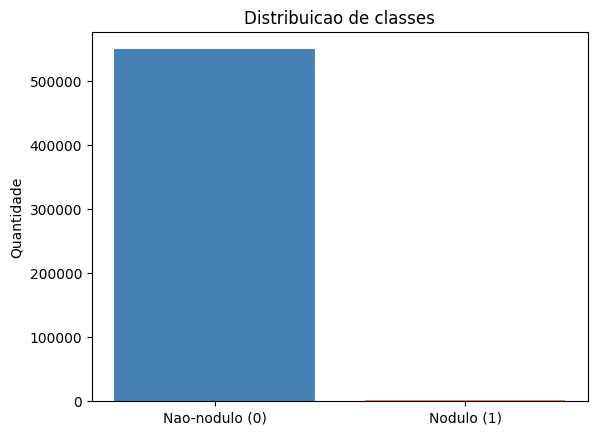

In [7]:
plt.bar(
    ["Nao-nodulo (0)", "Nodulo (1)"],
    class_counts.values,
    color=["steelblue", "coral"],
)
plt.ylabel("Quantidade")
plt.title("Distribuicao de classes")
plt.show()

Olha so: 407 nao-nodulos pra cada nodulo. Ou seja, se o modelo simplesmente chutar "nao e nodulo" pra tudo, ele acerta 99.75% das vezes. Mas nao encontra nenhum cancer -- que e exatamente o oposto do que a gente quer.

Vamos ver quantos candidatos cada CT scan tem:

In [8]:
candidates_per_scan = candidates_df.groupby("seriesuid").size()

print(f"Candidatos por CT scan:")
print(f"  Min:    {candidates_per_scan.min()}")
print(f"  Max:    {candidates_per_scan.max()}")
print(f"  Media:  {candidates_per_scan.mean():.1f}")
print(f"  Mediana: {candidates_per_scan.median():.1f}")
print(f"\nCTs unicos: {candidates_df['seriesuid'].nunique()}")

Candidatos por CT scan:
  Min:    32
  Max:    1468
  Media:  620.6
  Mediana: 582.5

CTs unicos: 888


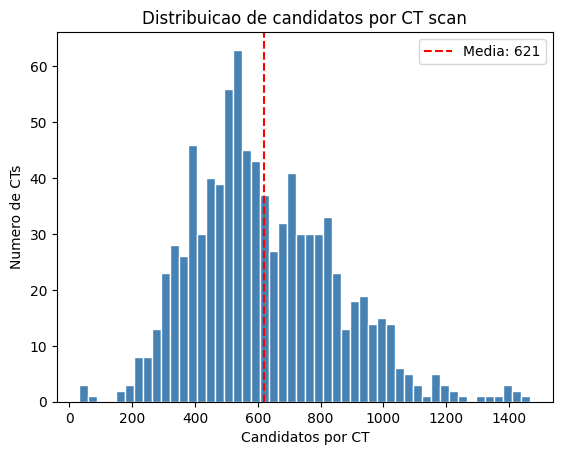

In [9]:
plt.hist(candidates_per_scan, bins=50, color="steelblue", edgecolor="white")
plt.axvline(candidates_per_scan.mean(), color="red", linestyle="--",
            label=f"Media: {candidates_per_scan.mean():.0f}")
plt.xlabel("Candidatos por CT")
plt.ylabel("Numero de CTs")
plt.title("Distribuicao de candidatos por CT scan")
plt.legend()
plt.show()

Em media, cada CT tem uns 620 candidatos. Faz sentido -- o algoritmo de deteccao que gerou esses candidatos e proposital sensivel (pra nao perder nenhum nodulo real), entao marca um monte de pontos.

E a distribuicao espacial dos candidatos?

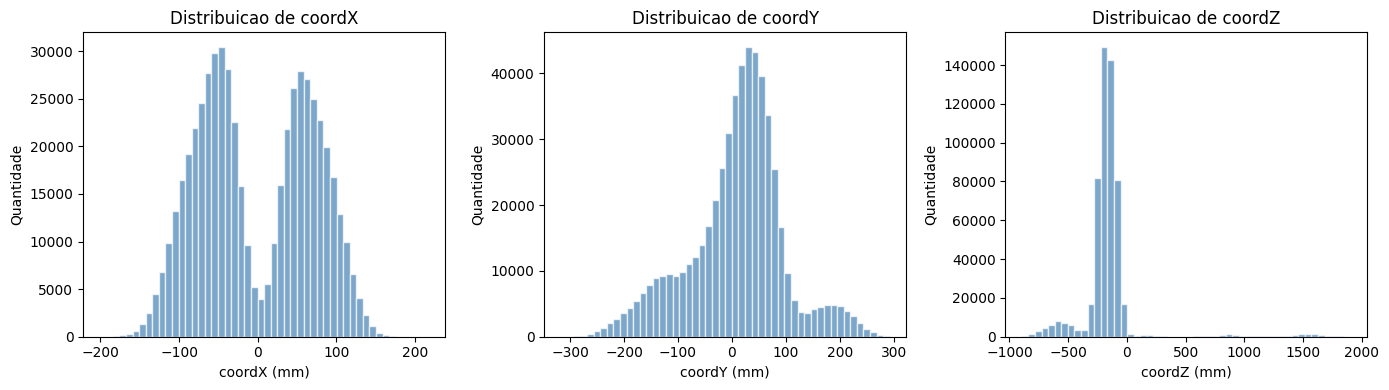

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, coord in zip(axes, ["coordX", "coordY", "coordZ"]):
    ax.hist(candidates_df[coord], bins=50, color="steelblue",
            edgecolor="white", alpha=0.7)
    ax.set_xlabel(f"{coord} (mm)")
    ax.set_ylabel("Quantidade")
    ax.set_title(f"Distribuicao de {coord}")
plt.tight_layout()
plt.show()

## Anotacoes

O `annotations.csv` traz os nodulos confirmados por especialistas, com o diametro de cada um. Vamos ver como os tamanhos se distribuem:

In [11]:
print("Diametro dos nodulos (mm):")
print(annotations_df["diameter_mm"].describe())

Diametro dos nodulos (mm):
count    1186.000000
mean        8.306527
std         4.762033
min         3.253443
25%         5.107177
50%         6.433600
75%         9.696301
max        32.270030
Name: diameter_mm, dtype: float64


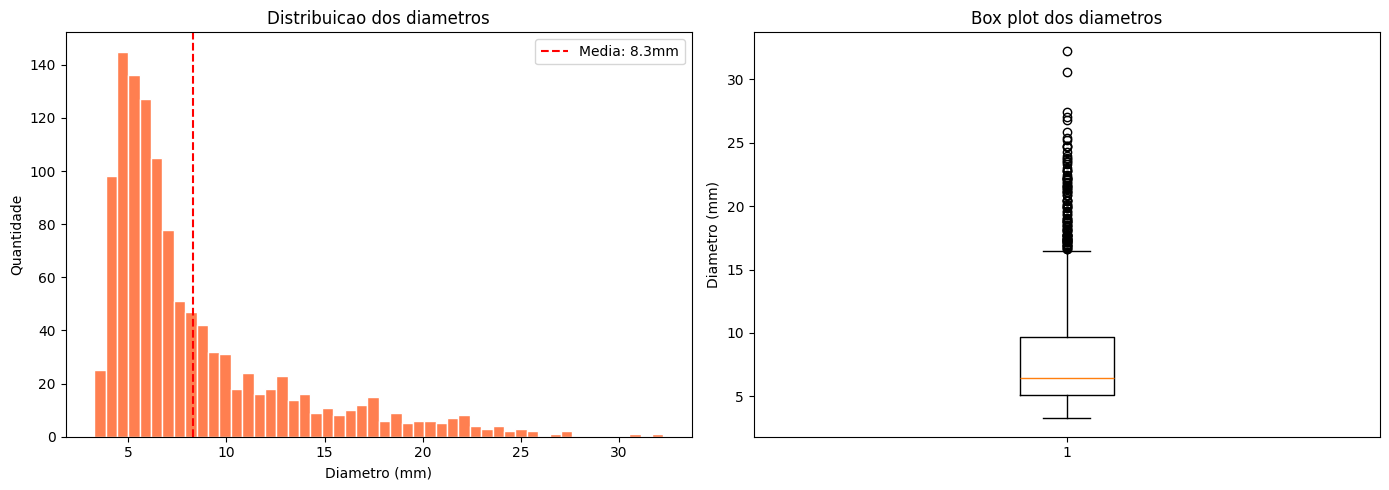

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(annotations_df["diameter_mm"], bins=50, color="coral", edgecolor="white")
axes[0].axvline(annotations_df["diameter_mm"].mean(), color="red", linestyle="--",
                label=f"Media: {annotations_df['diameter_mm'].mean():.1f}mm")
axes[0].set_xlabel("Diametro (mm)")
axes[0].set_ylabel("Quantidade")
axes[0].set_title("Distribuicao dos diametros")
axes[0].legend()

axes[1].boxplot(annotations_df["diameter_mm"], vert=True)
axes[1].set_ylabel("Diametro (mm)")
axes[1].set_title("Box plot dos diametros")

plt.tight_layout()
plt.show()

A maioria dos nodulos e pequena (mediana de ~6.4mm). Tem uns poucos grandoes de ate 32mm, mas sao excecao. Isso e importante porque nodulos pequenos sao mais dificeis de detectar.

E quantos nodulos cada CT tem?

In [13]:
nodules_per_scan = annotations_df.groupby("seriesuid").size()

print(f"Nodulos por CT:")
print(f"  Min:  {nodules_per_scan.min()}")
print(f"  Max:  {nodules_per_scan.max()}")
print(f"  Media: {nodules_per_scan.mean():.2f}")
print(f"\nCTs com nodulos: {annotations_df['seriesuid'].nunique()}")
print(f"\nDistribuicao:")
print(nodules_per_scan.value_counts().sort_index())

Nodulos por CT:
  Min:  1
  Max:  12
  Media: 1.97

CTs com nodulos: 601

Distribuicao:
1     310
2     159
3      63
4      24
5      23
6      11
7       4
8       2
9       4
12      1
Name: count, dtype: int64


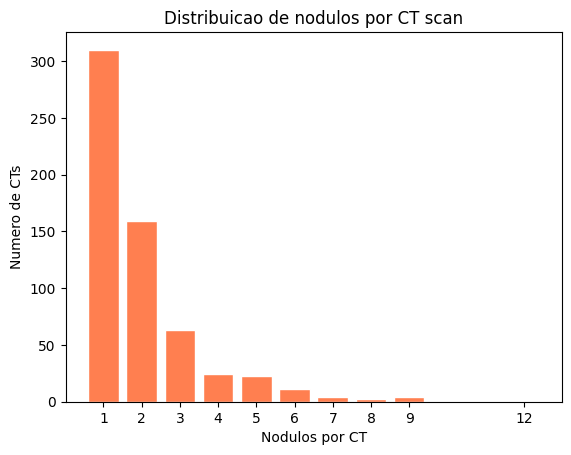

In [14]:
nodule_counts = nodules_per_scan.value_counts().sort_index()

plt.bar(nodule_counts.index, nodule_counts.values, color="coral", edgecolor="white")
plt.xlabel("Nodulos por CT")
plt.ylabel("Numero de CTs")
plt.title("Distribuicao de nodulos por CT scan")
plt.xticks(nodule_counts.index)
plt.show()

A maioria dos CTs com nodulo tem 1 ou 2. Mas tem casos com ate 12 nodulos no mesmo scan. Interessante.

## Cruzando os dados

Vamos ver como os dois CSVs se relacionam. Todo CT que aparece em `annotations.csv` tambem aparece em `candidates.csv`?

In [15]:
candidates_series = set(candidates_df["seriesuid"].unique())
annotations_series = set(annotations_df["seriesuid"].unique())

print(f"Series em candidates.csv: {len(candidates_series)}")
print(f"Series em annotations.csv: {len(annotations_series)}")
print(f"Em ambos: {len(candidates_series & annotations_series)}")
print(f"So em candidates: {len(candidates_series - annotations_series)}")
print(f"So em annotations: {len(annotations_series - candidates_series)}")

Series em candidates.csv: 888
Series em annotations.csv: 601
Em ambos: 601
So em candidates: 287
So em annotations: 0


Todos os CTs de annotations tambem estao em candidates. Os 287 que ficam "so em candidates" sao CTs sem nenhum nodulo confirmado (tem candidatos, mas todos sao negativos).

Repare que o numero de candidatos positivos (1.351) e maior que o numero de anotacoes (1.186). Isso acontece porque o sistema de deteccao pode marcar o mesmo nodulo mais de uma vez, com coordenadas ligeiramente diferentes.

In [16]:
positive_candidates = candidates_df[candidates_df["class"] == 1]

print(f"Candidatos positivos (class=1): {len(positive_candidates)}")
print(f"Anotacoes: {len(annotations_df)}")
print(f"Diferenca: {len(positive_candidates) - len(annotations_df)}")

Candidatos positivos (class=1): 1351
Anotacoes: 1186
Diferenca: 165


## Resumo

O que a gente aprendeu ate aqui:

In [17]:
print(f"Total de CTs: {len(candidates_series)}")
print(f"CTs com nodulos: {len(annotations_series)}")
print(f"")
print(f"Candidatos: {len(candidates_df):,}")
print(f"  Positivos: {class_counts[1]:,} ({class_counts[1]/len(candidates_df)*100:.2f}%)")
print(f"  Negativos: {class_counts[0]:,} ({class_counts[0]/len(candidates_df)*100:.2f}%)")
print(f"  Desbalanceamento: {class_counts[0]/class_counts[1]:.0f}:1")
print(f"")
print(f"Nodulos confirmados: {len(annotations_df):,}")
print(f"  Diametro: {annotations_df['diameter_mm'].min():.1f}mm a {annotations_df['diameter_mm'].max():.1f}mm")
print(f"  Media: {annotations_df['diameter_mm'].mean():.1f}mm")

Total de CTs: 888
CTs com nodulos: 601

Candidatos: 551,065
  Positivos: 1,351 (0.25%)
  Negativos: 549,714 (99.75%)
  Desbalanceamento: 407:1

Nodulos confirmados: 1,186
  Diametro: 3.3mm a 32.3mm
  Media: 8.3mm


## Proximos passos

Os CSVs tem coordenadas em milimetros, mas elas nao batem exatamente entre os dois arquivos. No proximo notebook, a gente vai analisar essas diferencas e entender como unificar as duas fontes de dados.